<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/Week5_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Mohamat Fauzi Rohman'
NIM = '244107020067' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Mohamat Fauzi Rohman
NIM : 244107020067 | N = 67
bins   : 64
clip   : 2.0
tile   : 5
L      : 4
WAKTU : 2026-09-22 23:11:10 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 424898a6928ed78a


#E. PERCOBAAN PRAKTIKUM


**E-1 PERCOBAAN HISTOGRAM**

1. Buka https://colab.research.google.com/. Setelah dipastikan bahwa Google Colab
terhubung dengan GitHub Anda, lanjutkan dengan memilih repository yang telah
digunakan pada praktikum minggu lalu, lalu ubah nama berkas menjadi
"Week5_No Absen.ipynb".
Kemudian import folder yang ada di Drive Anda dengan cara sebagai berikut.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-5 berikut.

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra
contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

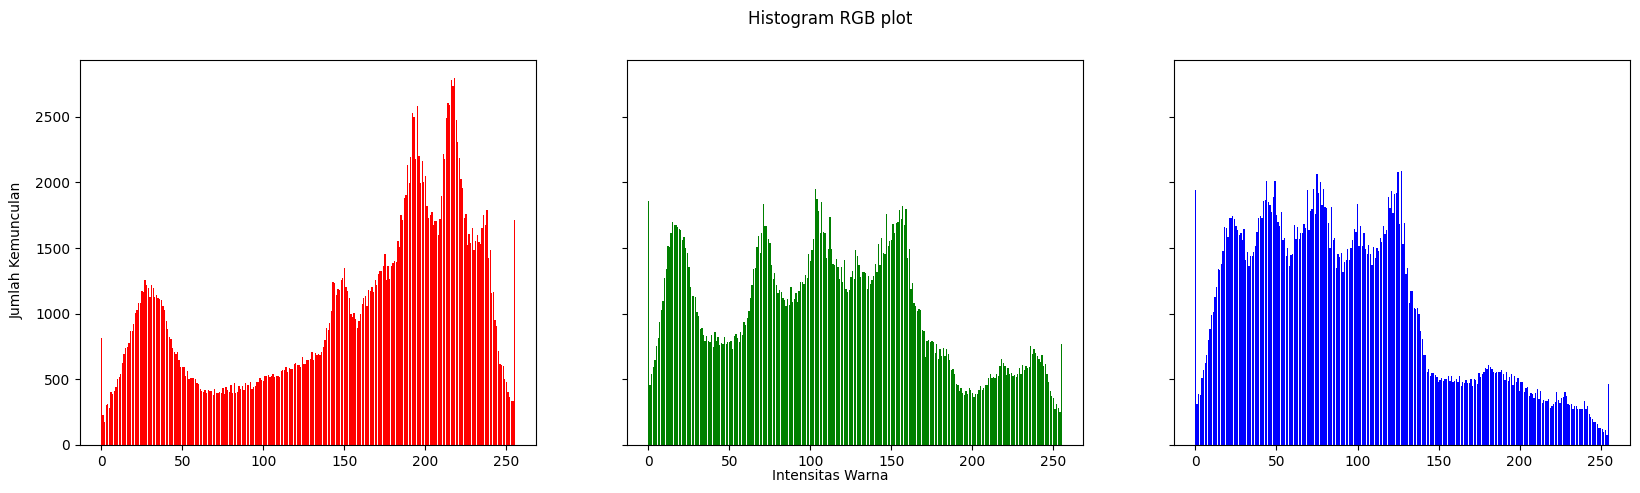

In [4]:
#membuat histogram image (manual) lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

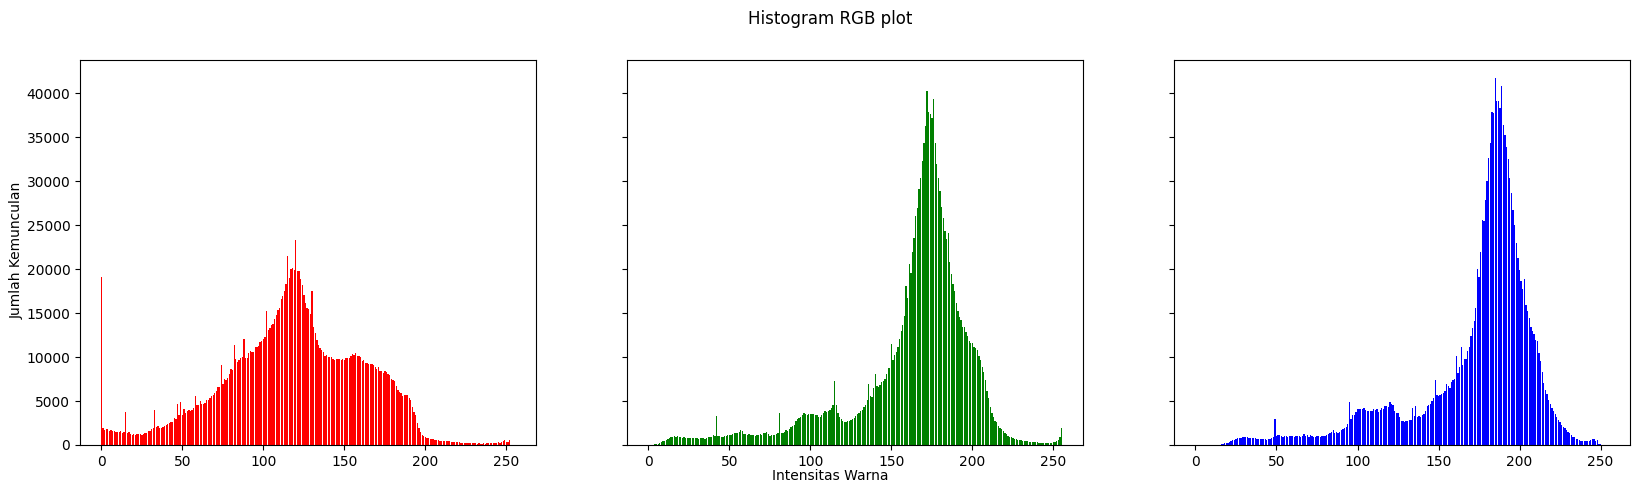

In [5]:
#membuat histogram image (manual) KTP1b.jpeg
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/KTP1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**PERTANYAAN PRAKTIKUM E1**
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.


In [16]:
def hitung_hist_manual(gray):
    h = np.zeros(256, dtype=np.int64)
    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            h[gray[y, x]] += 1
    return h


def uji_kesamaan_histogram(path_citra, label_citra):
    gray = cv.imread(path_citra, cv.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"Gagal membaca: {path_citra}")
        return

    #manual
    h_manual = hitung_hist_manual(gray)
    #NumPy
    h_numpy, _ = np.histogram(gray.ravel(), bins=256, range=[0, 256])
    #OpenCV
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    #menghitung selisih maksimum
    diff_manual_np = np.max(np.abs(h_manual - h_numpy))
    diff_manual_cv = np.max(np.abs(h_manual - h_cv))
    diff_np_cv = np.max(np.abs(h_numpy - h_cv))

    print(f"=== Pembuktian untuk {label_citra} ===")
    print(f"Maks Selisih Manual - NumPy: {diff_manual_np}")
    print(f"Maks Selisih Manual - OpenCV : {diff_manual_cv}")
    print(f"Maks Selisih NumPy - OpenCV : {diff_np_cv}")
    print()


#path dasar folder citra
BASE_DIR = "/content/drive/MyDrive/PCVK/Images/244107020067/"

#verifikasi pada lena.jpg
path_lena = BASE_DIR + "lena.jpg"
uji_kesamaan_histogram(path_lena, "lena.jpg")

#verifikasi pada KTP1b.jpeg
path_ktm = BASE_DIR + "KTP1b.jpeg"
uji_kesamaan_histogram(path_ktm, "KTM1b.jpg")

=== Pembuktian untuk lena.jpg ===
Maks Selisih Manual - NumPy: 0
Maks Selisih Manual - OpenCV : 0
Maks Selisih NumPy - OpenCV : 0

=== Pembuktian untuk KTM1b.jpg ===
Maks Selisih Manual - NumPy: 0
Maks Selisih Manual - OpenCV : 0
Maks Selisih NumPy - OpenCV : 0



2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

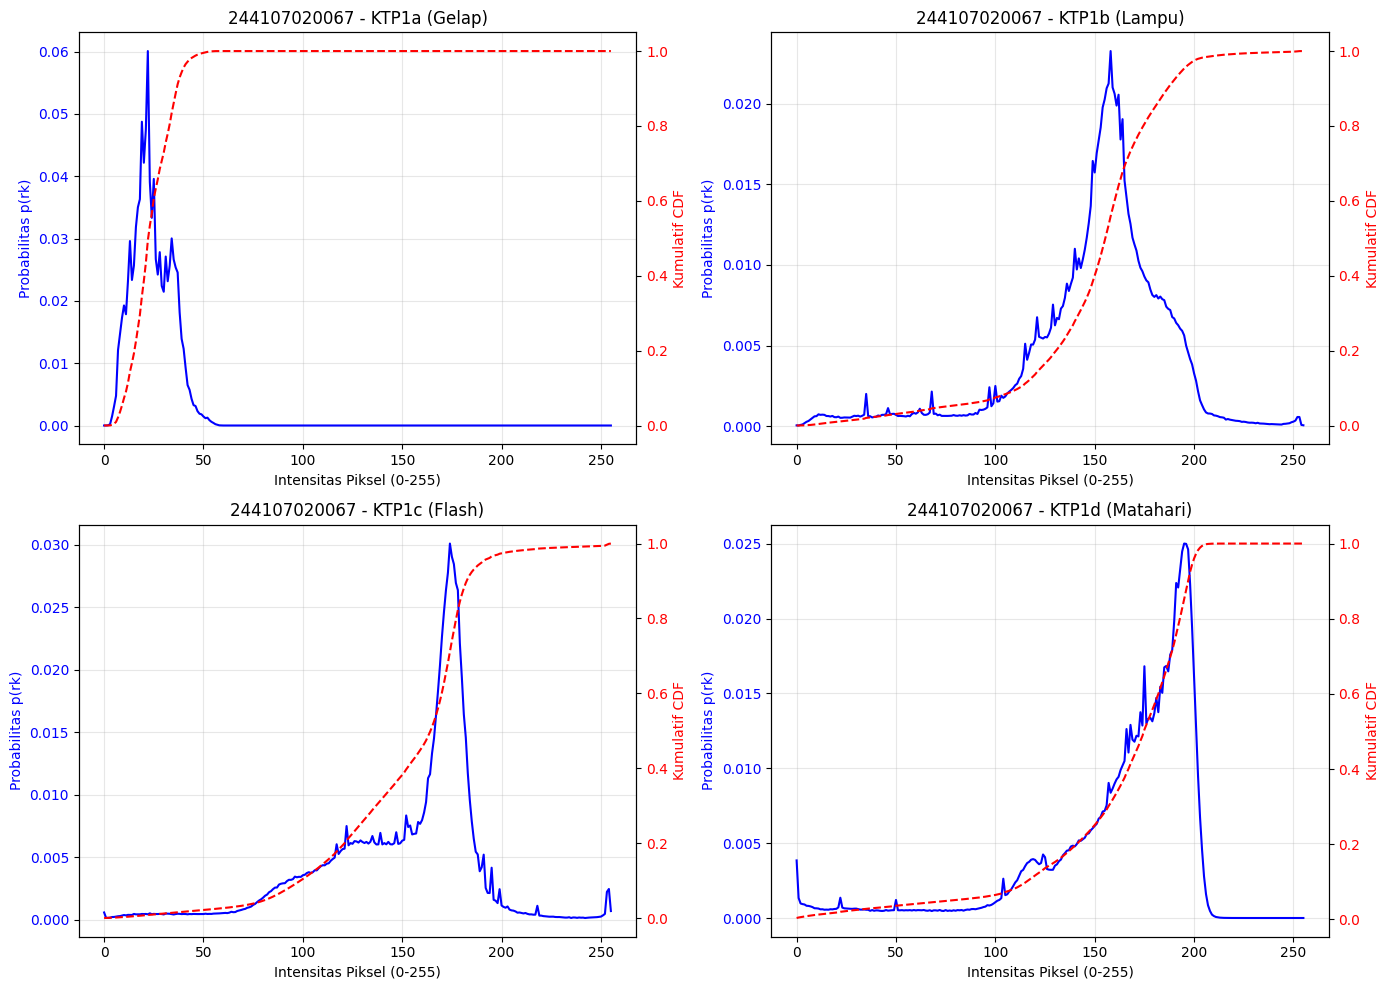

In [21]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'

files = ['KTP1a.jpeg', 'KTP1b.jpeg', 'KTP1c.jpeg', 'KTP1d.jpeg']
labels = ['KTP1a (Gelap)', 'KTP1b (Lampu)', 'KTP1c (Flash)', 'KTP1d (Matahari)']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for i, (fn, lbl) in enumerate(zip(files, labels)):
  img = cv.imread(BASE_DIR + '/' + fn, cv.IMREAD_GRAYSCALE)
  h = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
  p = h / img.size
  cdf = np.cumsum(p)  #CDF

  ax = axs[i]
  ax.plot(p, color='blue', label='p(rk) - Normalisasi')
  ax.set_ylabel('Probabilitas p(rk)', color='blue')
  ax.tick_params(axis='y', labelcolor='blue')

  ax2 = ax.twinx()
  ax2.plot(cdf, color='red', linestyle='--', label='CDF')
  ax2.set_ylabel('Kumulatif CDF', color='red')
  ax2.tick_params(axis='y', labelcolor='red')

  ax.set_title(f'{NIM} - {lbl}')
  ax.set_xlabel('Intensitas Piksel (0-255)')
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Citra Paling Gelap yaitu KTP1a : untuk pikselnya menumpuk di sebelah kiri dimana mendekati 0/intensitas rendah. Kurva CDF melonjak sangat tinggi di awal rentang intensitas dan langsung mendatar mendekati nilai 1 sebelum mencapai pertengahan intensitas abu-abu yang menandakan pencahayaan ruangan yang minim

- Citra Paling Terang yaitu KTP1d: untuk pikselnya berada signifikan di sisi kanan yang mendekati 255/intensitas tinggi. Kurva CDF berada di nilai mendekati 0 cukup lama dan baru melonjak tinggi saat mendekati nilai 255

- Hubungan dengan Akuisisi: Sudut kemiringan dan titik kenaikan CDF menandakan secara akurat tentang kondisi pencahayaan di lapangan saat akuisisi citra

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

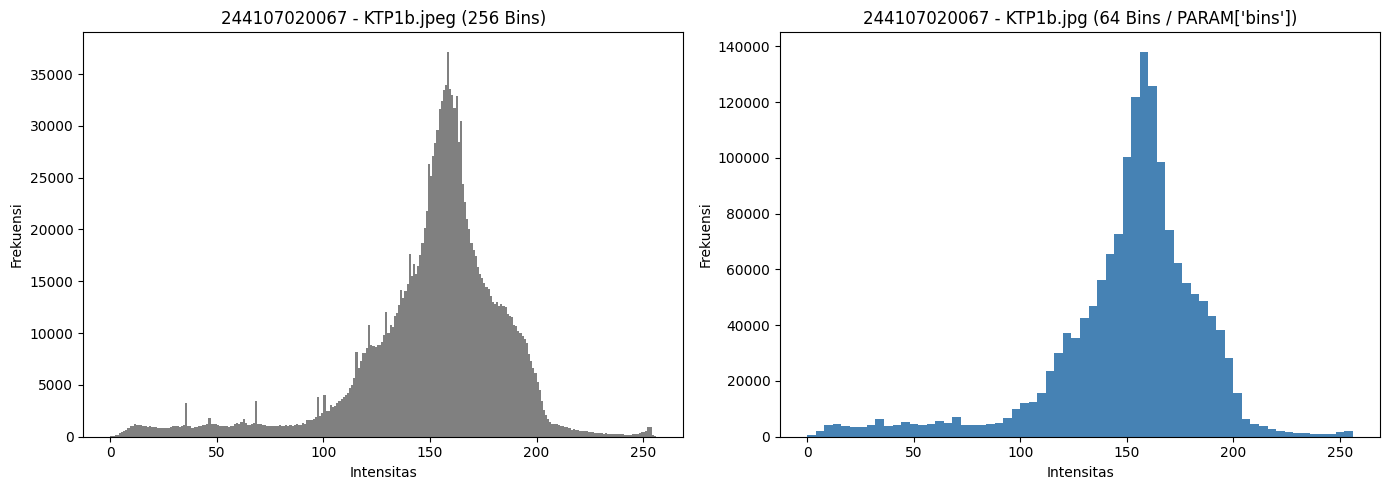

In [25]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'

img_ktp1b = cv.imread(BASE_DIR + '/KTP1b.jpeg', cv.IMREAD_GRAYSCALE)
n_bins = PARAM['bins']

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#256 Bins
axs[0].hist(img_ktp1b.ravel(), bins=256, range=[0, 256], color='gray')
axs[0].set_title(f'{NIM} - KTP1b.jpeg (256 Bins)')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Frekuensi')

#PARAM['bins']
axs[1].hist(img_ktp1b.ravel(), bins=n_bins, range=[0, 256], color='steelblue')
axs[1].set_title(f"{NIM} - KTP1b.jpg ({n_bins} Bins / PARAM['bins'])")
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Informasi yang Hilang saat Bin Dikurangi:

Ketika jumlah bin dikurangi maka yang terjadi ialah mengalami proses binning atau bisa disebut pengelompokan beberapa derajat keabuan berdekatan ke dalam interval nilai yang lebih lebar

**E-2 PERCOBAAN *HISTOGRAM EQUALIZATION***

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

 Tahap 1: lena_lc.jpg 


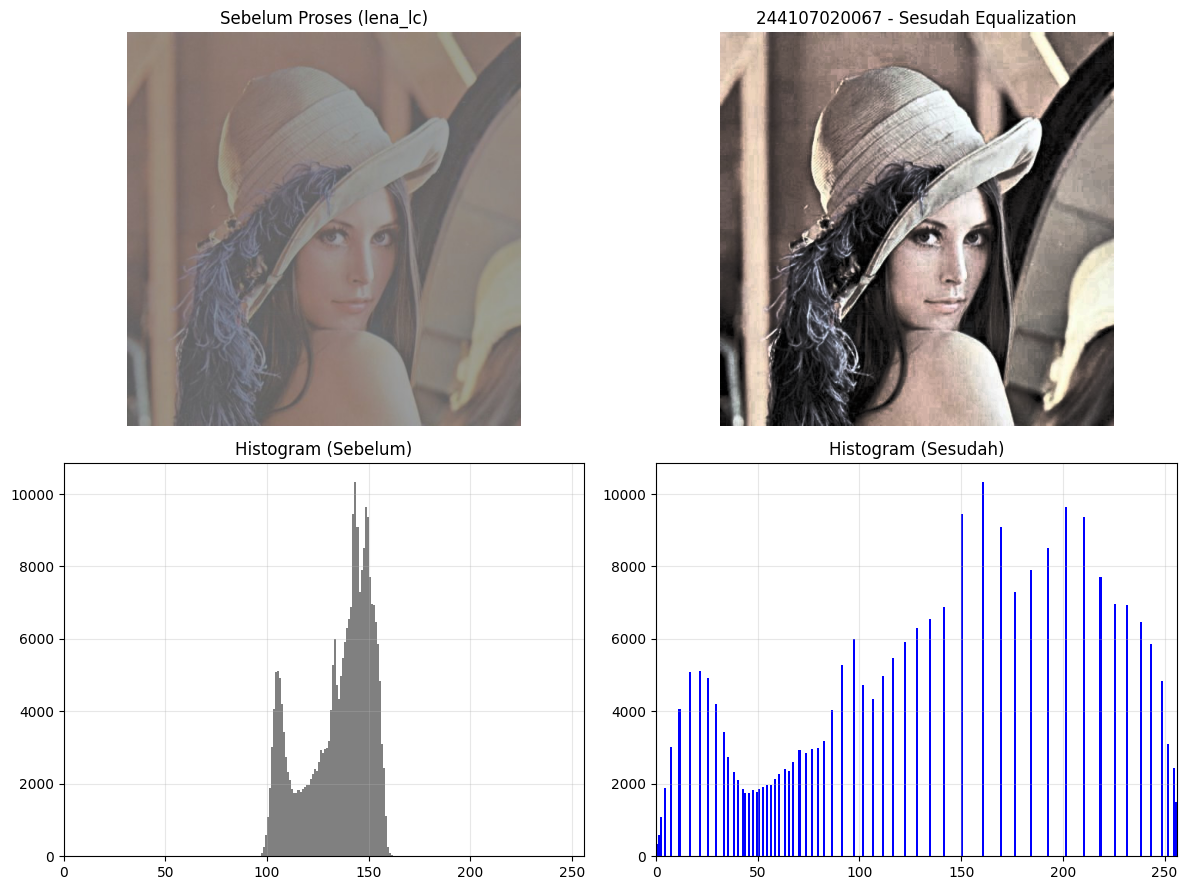


Tahap 2: KTP1a.jpg 


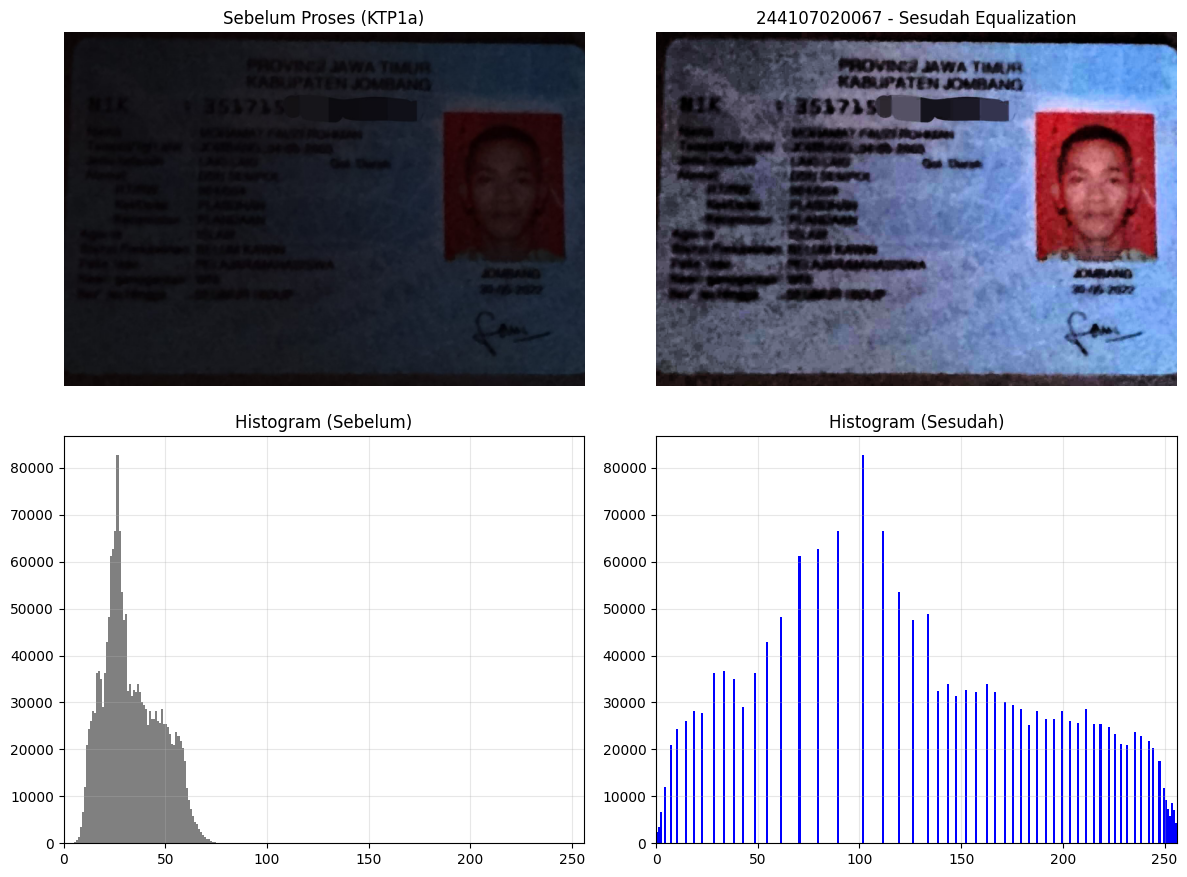

In [44]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'


def he_manual_channel(channel):
  #menghitung histogram manual
  h = np.zeros(256, dtype=np.int64)
  for y in range(channel.shape[0]):
    for x in range(channel.shape[1]):
      h[channel[y, x]] += 1

  #PDF, CDF, dan Mapping T(r) = round(CDF * 255)
  cdf = np.cumsum(h / channel.size)
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[channel]


def proses_dan_tampilkan(path_citra, judul_citra):
  bgr = cv.imread(path_citra)
  if bgr is None:
    print(f'Gagal membaca: {path_citra}')
    return

  #konversi warna & proses kanal V
  rgb_sebelum = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
  h, s, v = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2HSV))
  v_ekual = he_manual_channel(v)
  rgb_sesudah = cv.cvtColor(cv.merge([h, s, v_ekual]), cv.COLOR_HSV2RGB)

  #visualisasi
  fig, axs = plt.subplots(2, 2, figsize=(12, 9))

  #citra sebelum & sesudah
  axs[0, 0].imshow(rgb_sebelum)
  axs[0, 0].set_title(f'Sebelum Proses ({judul_citra})')
  axs[0, 1].imshow(rgb_sesudah)
  axs[0, 1].set_title(f'{NIM} - Sesudah Equalization')
  axs[0, 0].axis('off')
  axs[0, 1].axis('off')

  #histogram sebelum & sesudah
  for ax, data, color, title in zip(
      axs[1],
      [v, v_ekual],
      ['gray', 'blue'],
      ['Histogram (Sebelum)', 'Histogram (Sesudah)'],
  ):
    ax.hist(data.ravel(), bins=256, range=[0, 256], color=color)
    ax.set_title(title)
    ax.set_xlim([0, 256])
    ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()


#tahap 1: lena_lc.jpg
print(' Tahap 1: lena_lc.jpg ')
proses_dan_tampilkan(os.path.join(BASE_DIR, 'lena_lc.jpg'), 'lena_lc')

#tahap 2: KTP1a.jpg
print('\nTahap 2: KTP1a.jpg ')
proses_dan_tampilkan(os.path.join(BASE_DIR, 'KTP1a.jpeg'), 'KTP1a')

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini. Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.



Perbandingan untuk lena_lc
Selisih Maksimum Kanal Blue  : 0
Selisih Maksimum Kanal Green : 0
Selisih Maksimum Kanal Red   : 0


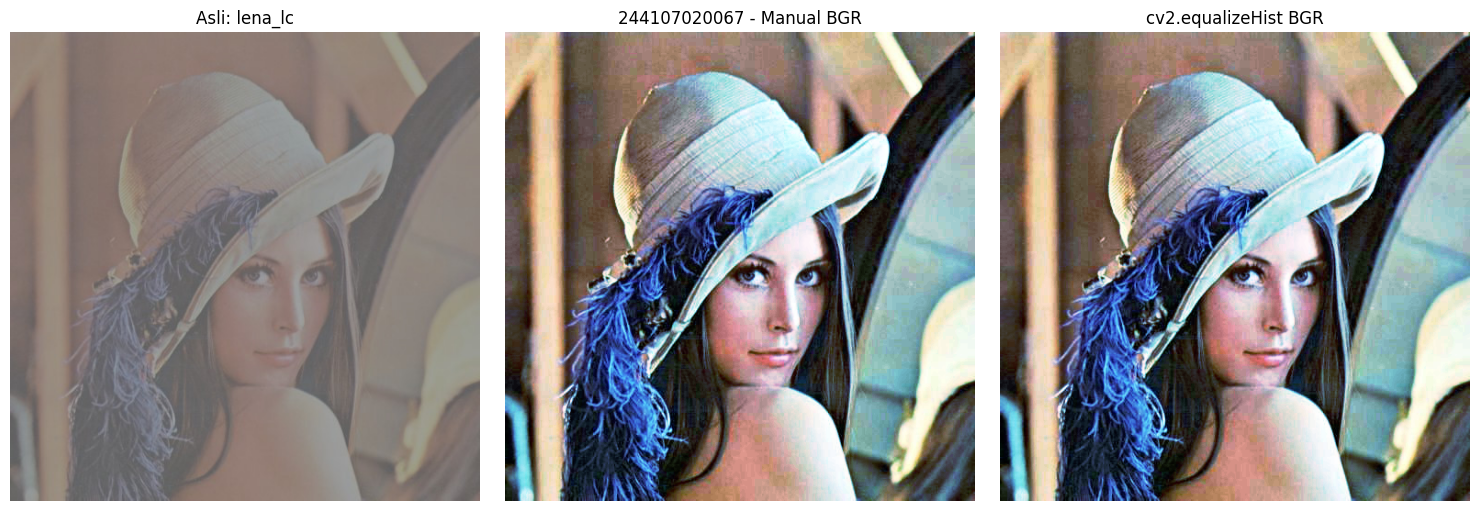



Perbandingan untuk KTP1a
Selisih Maksimum Kanal Blue  : 1
Selisih Maksimum Kanal Green : 1
Selisih Maksimum Kanal Red   : 0


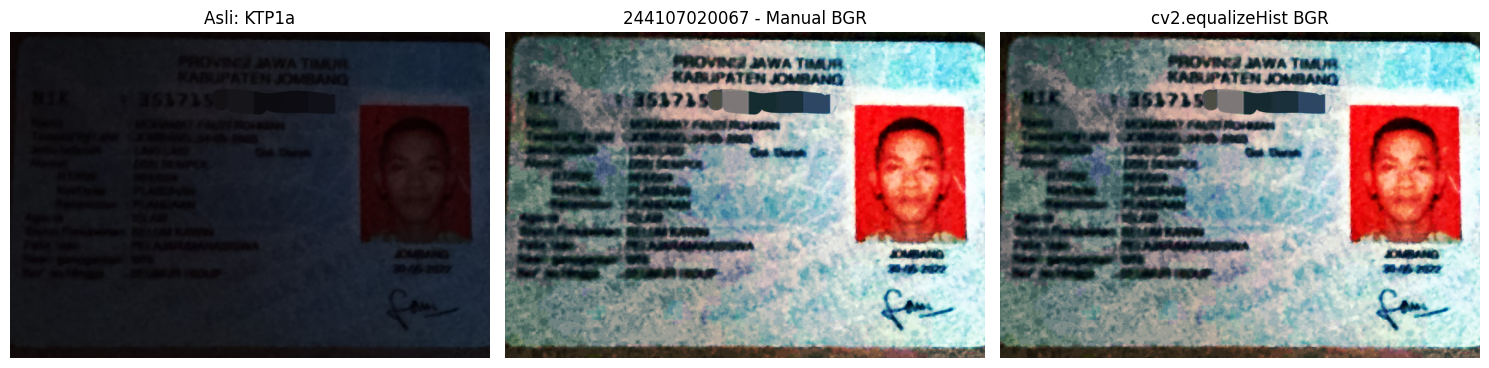

In [50]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'


def he_manual_channel(channel):
  h = np.zeros(256, dtype=np.int64)
  for y in range(channel.shape[0]):
    for x in range(channel.shape[1]):
      h[channel[y, x]] += 1

  cdf = np.cumsum(h / channel.size)
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[channel]


def evaluasi_soal_2(path_citra, label_citra):
  image = cv.imread(path_citra)
  if image is None:
    print(f'Gagal membaca file: {path_citra}')
    return

  #ekualisasi menggunakan cv2.equalizeHist per kanal BGR
  b, g, r = cv.split(image)
  b_equalized = cv.equalizeHist(b)
  g_equalized = cv.equalizeHist(g)
  r_equalized = cv.equalizeHist(r)
  hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

  #ekualisasi Manual per kanal BGR
  b_manual = he_manual_channel(b)
  g_manual = he_manual_channel(g)
  r_manual = he_manual_channel(r)
  hasil_manual = cv.merge([b_manual, g_manual, r_manual])

  #menghitung selisih maksimum antar kanal
  diff_b = np.max(np.abs(b_manual.astype(int) - b_equalized.astype(int)))
  diff_g = np.max(np.abs(g_manual.astype(int) - g_equalized.astype(int)))
  diff_r = np.max(np.abs(r_manual.astype(int) - r_equalized.astype(int)))

  print()
  print(f'\nPerbandingan untuk {label_citra}')
  print(f'Selisih Maksimum Kanal Blue  : {diff_b}')
  print(f'Selisih Maksimum Kanal Green : {diff_g}')
  print(f'Selisih Maksimum Kanal Red   : {diff_r}')


  #menampilkan visualisasi perbandingan
  rgb_asli = cv.cvtColor(image, cv.COLOR_BGR2RGB)
  rgb_manual = cv.cvtColor(hasil_manual, cv.COLOR_BGR2RGB)
  rgb_cv = cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB)

  fig, axs = plt.subplots(1, 3, figsize=(15, 5))
  axs[0].imshow(rgb_asli)
  axs[0].set_title(f'Asli: {label_citra}')
  axs[0].axis('off')

  axs[1].imshow(rgb_manual)
  axs[1].set_title(f'{NIM} - Manual BGR')
  axs[1].axis('off')

  axs[2].imshow(rgb_cv)
  axs[2].set_title('cv2.equalizeHist BGR')
  axs[2].axis('off')

  plt.tight_layout()
  plt.show()

evaluasi_soal_2(os.path.join(BASE_DIR, 'lena_lc.jpg'), 'lena_lc')
evaluasi_soal_2(os.path.join(BASE_DIR, 'KTP1a.jpeg'), 'KTP1a')

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

Tahap 1: lena.jpg


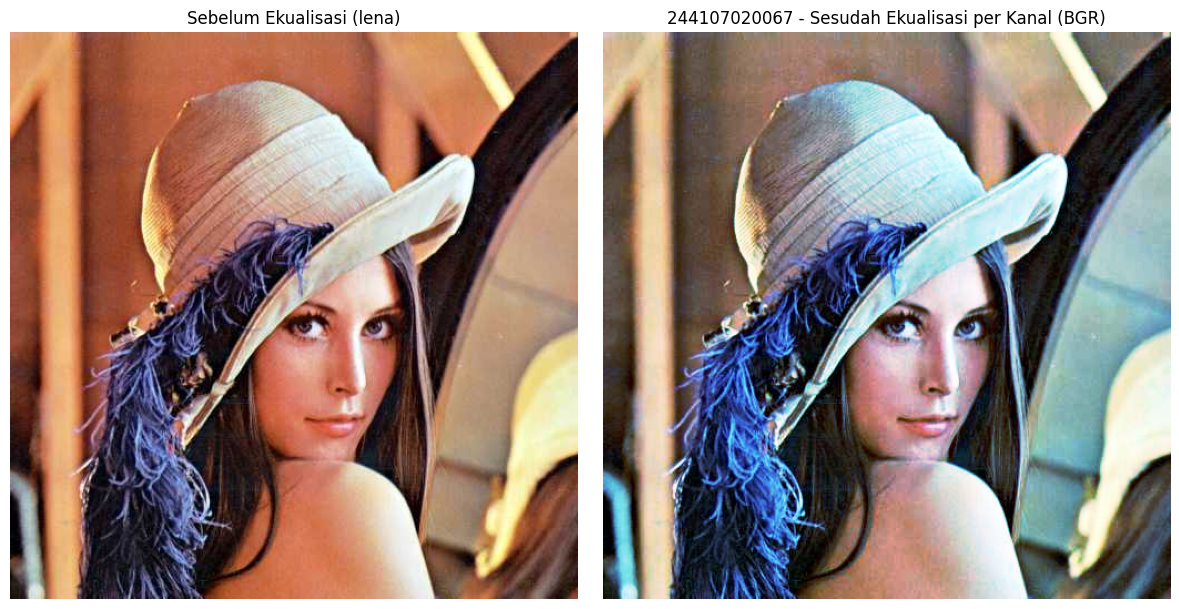


Tahap 2: KTP1d.jpg


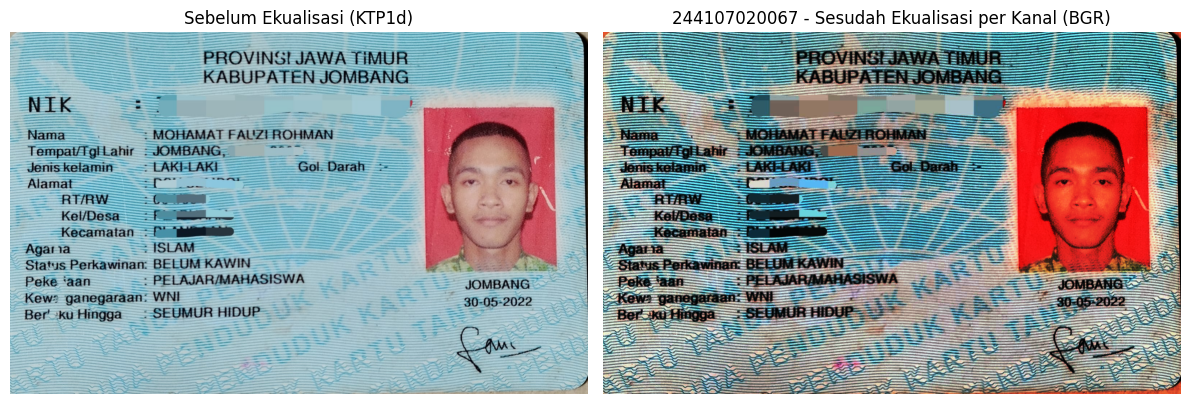

In [57]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'


def ekualisasi_per_kanal(path_citra, label_citra):
  bgr = cv.imread(path_citra)
  if bgr is None:
    print(f'Gagal membaca berkas: {path_citra}')
    return

  #tiap kanal diekualisasi sendiri-sendiri
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_bgr = cv.merge(kanal)

  #konversi ke RGB untuk penampil Matplotlib
  rgb_sebelum = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
  rgb_sesudah = cv.cvtColor(he_bgr, cv.COLOR_BGR2RGB)

  #visualisasi perbandingan citra
  fig, axs = plt.subplots(1, 2, figsize=(12, 6))

  axs[0].imshow(rgb_sebelum)
  axs[0].set_title(f'Sebelum Ekualisasi ({label_citra})')
  axs[0].axis('off')

  axs[1].imshow(rgb_sesudah)
  axs[1].set_title(f'{NIM} - Sesudah Ekualisasi per Kanal (BGR)')
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()

print('Tahap 1: lena.jpg')
ekualisasi_per_kanal(os.path.join(BASE_DIR, 'lena.jpg'), 'lena')

print('\nTahap 2: KTP1d.jpg')
ekualisasi_per_kanal(os.path.join(BASE_DIR, 'KTP1d.jpeg'), 'KTP1d')

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)

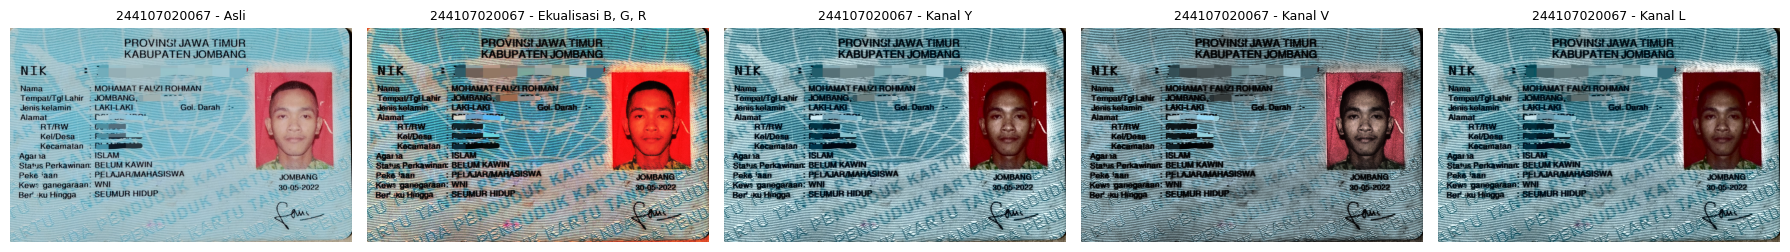


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            163.3
Ekualisasi B, G, R                50.47            128.4
Kanal Y                            1.46            129.5
Kanal V                            1.37            112.6
Kanal L                            2.16            120.3


In [59]:
BASE_DIR = '/content/drive/MyDrive/PCVK/Images/244107020067/'
NIM = '244107020067'

# Baca citra KTM1d.jpg (sesuaikan nama berkas jika KTP1d.jpg / KTM1d.jpg)
path_ktm = os.path.join(BASE_DIR, 'KTP1d.jpeg')
bgr = cv.imread(path_ktm)

if bgr is None:
  print(f'Gagal membaca file: {path_ktm}')
else:
  # -------------------------------------------------------------
  # Cara 1: Ekualisasi B, G, R terpisah (dari langkah 3)
  # -------------------------------------------------------------
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb = cv.merge(kanal)

  # -------------------------------------------------------------
  # Cara 2: Memisahkan kecerahan dari informasi warna
  # -------------------------------------------------------------
  # 1. Ruang Warna YCrCb (Kanal Y)
  ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(
      cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR
  )

  # 2. Ruang Warna HSV (Kanal V)
  hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
  h, sat, v = cv.split(hsv)
  he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

  # 3. Ruang Warna LAB (Kanal L)
  lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
  l, a, b_k = cv.split(lab)
  he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_k]), cv.COLOR_LAB2BGR)

  # -------------------------------------------------------------
  # Tampilkan kelimanya berdampingan
  # -------------------------------------------------------------
  judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
  citra = [bgr, he_rgb, he_y, he_v, he_l]

  plt.figure(figsize=(18, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
  plt.tight_layout()
  plt.show()

  # -------------------------------------------------------------
  # Fungsi Pergeseran Hue dan Analisis Kuantitatif
  # -------------------------------------------------------------
  def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
    return d.mean()

  print('\n' + '=' * 60)
  print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
  print('=' * 60)
  for t, c in zip(judul, citra):
    print(
        '%-22s %16.2f %16.1f'
        % (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean(),
        )
    )
  print('=' * 60)

**PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM Anda
    
    a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale.
    
    b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

    c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

    a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

    b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.

**E-3 TUGAS PRAKTIKUM *DITHERING***

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.